In [1]:
# Cartpole-Pybullet Trajectory Classification with 1D CNN (1000 training trajectories)
# Balanced dataset with class weights

In [2]:
!nvidia-smi

Mon Nov 10 19:33:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.20             Driver Version: 570.133.20     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1660 ...    Off |   00000000:01:00.0 Off |                  N/A |
| 34%   33C    P8              9W /  125W |      86MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Import libraries
missing_packages = []
try:
    import numpy as np
    print(f"✓ NumPy {np.__version__}")
except ImportError:
    missing_packages.append("numpy")
    print("✗ NumPy not installed")

try:
    import torch
    print(f"✓ PyTorch {torch.__version__}")
    print(f"  CUDA available: {torch.cuda.is_available()}")
except ImportError:
    missing_packages.append("torch")
    print("✗ PyTorch not installed")

try:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__}")
except ImportError:
    missing_packages.append("scikit-learn")
    print("✗ scikit-learn not installed")

try:
    import matplotlib.pyplot as plt
    print(f"✓ matplotlib")
except ImportError:
    missing_packages.append("matplotlib")
    print("✗ matplotlib not installed")

if missing_packages:
    print(f"\n⚠️  MISSING PACKAGES: {', '.join(missing_packages)}")
    print("\nTo install, run this in a terminal:")
    print(f"  pip install {' '.join(missing_packages)}")
    raise ImportError(f"Please install missing packages: {', '.join(missing_packages)}")

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

print("\n✓ All libraries imported successfully!")


✓ NumPy 2.3.3
✓ PyTorch 2.5.1+cu124
  CUDA available: True
✓ scikit-learn 1.7.2
✓ matplotlib

✓ All libraries imported successfully!


In [4]:
import numpy as np

# Load training data: Extract first 1000 sequences from shuffled_indices.txt
# Each trajectory is broken into individual data points (timesteps)
# Each data point gets the trajectory's label from roa_labels.txt

# Load shuffled indices to determine order
with open('shuffled_indices.txt', 'r') as f:
    shuffled_sequences = [line.strip() for line in f.readlines()]

# Load labels from roa_labels.txt
# Row N in roa_labels.txt corresponds to line N in shuffled_indices.txt
labels_data = np.loadtxt('roa_labels.txt', delimiter=',')
labels = labels_data[:, -1].astype(int)

# Extract first 1000 sequences for training
train_size = 1000
train_sequences = shuffled_sequences[:train_size]

# Validation: next 500 sequences
val_size = 500
val_sequences = shuffled_sequences[train_size:train_size + val_size]

# Transform function: [x, theta, x_dot, theta_dot] -> [x, sin(theta), cos(theta), x_dot, theta_dot]
def transform_theta_to_sincos_timestep(timestep):
    """
    Transform a single data point (timestep).
    Input: [x, theta, x_dot, theta_dot] (4 features)
    Output: [x, sin(theta), cos(theta), x_dot, theta_dot] (5 features)
    """
    x = timestep[0]
    theta = timestep[1]  # 2nd element (index 1)
    x_dot = timestep[2]
    theta_dot = timestep[3]
    
    # Transform theta to sin/cos
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    
    # Return: [x, sin(theta), cos(theta), x_dot, theta_dot]
    return np.array([x, sin_theta, cos_theta, x_dot, theta_dot], dtype=np.float32)

def load_individual_datapoints(sequence_files, labels, start_index, set_name):
    """
    Load trajectories and break them into individual data points.
    Each timestep becomes a separate datapoint with the trajectory's label.
    
    Args:
        sequence_files: List of sequence filenames
        labels: Array of labels from roa_labels.txt
        start_index: Starting index in shuffled_indices.txt (for label mapping)
        set_name: Name for logging
    
    Returns:
        X: Array of shape (num_datapoints, 5) - individual state vectors
        y: Array of shape (num_datapoints,) - labels (1 or 0)
    """
    X_datapoints = []
    y_datapoints = []
    traj_dir = 'trajectories'
    
    print(f"\nLoading {set_name} data...")
    print(f"  Processing {len(sequence_files)} trajectories...")
    valid_count = 0
    
    for idx, seq_file in enumerate(sequence_files):
        traj_path = f'{traj_dir}/{seq_file}'
        
        # Check if file exists
        import os
        if not os.path.exists(traj_path):
            continue
        
        # Load trajectory file (each line is a state vector: [x, theta, x_dot, theta_dot])
        trajectory = np.loadtxt(traj_path, delimiter=',')
        if trajectory.ndim == 1:
            # Single timestep trajectory
            trajectory = trajectory.reshape(1, -1)
        
        # Get label from roa_labels.txt
        # row_idx in roa_labels.txt corresponds to position in shuffled_indices.txt
        row_idx = start_index + idx
        trajectory_label = labels[row_idx]  # This trajectory's label (1 or 0)
        
        # Break trajectory into individual data points
        # Each timestep becomes a separate datapoint with the trajectory's label
        for timestep in trajectory:
            # Transform: [x, theta, x_dot, theta_dot] -> [x, sin(theta), cos(theta), x_dot, theta_dot]
            datapoint = transform_theta_to_sincos_timestep(timestep)
            X_datapoints.append(datapoint)
            y_datapoints.append(trajectory_label)  # All timesteps from this trajectory get the same label
        
        valid_count += 1
        if valid_count % 500 == 0:
            print(f"  Processed {valid_count}/{len(sequence_files)} trajectories...")
    
    X_datapoints = np.array(X_datapoints, dtype=np.float32)
    y_datapoints = np.array(y_datapoints, dtype=np.int64)
    
    print(f"✓ Loaded {valid_count} trajectories")
    print(f"  Total individual datapoints: {len(X_datapoints)}")
    print(f"  X shape: {X_datapoints.shape}  (datapoints, features)")
    print(f"  y shape: {y_datapoints.shape}  (labels)")
    print(f"  Success rate: {np.mean(y_datapoints == 1):.2%}")
    print(f"  Failure rate: {np.mean(y_datapoints == 0):.2%}")
    
    return X_datapoints, y_datapoints

X_train, y_train = load_individual_datapoints(train_sequences, labels, start_index=0, set_name="training")

X_val, y_val = load_individual_datapoints(val_sequences, labels, start_index=train_size, set_name="validation")

feature_max = np.abs(X_train).max(axis=0) 
print(f"Feature max values (per feature): {feature_max}")

# for X-train and x-val, normalize [0], [3], [4] only
X_train[:, [0, 3, 4]] = X_train[:, [0, 3, 4]] / feature_max[[0, 3, 4]]
X_val[:, [0, 3, 4]] = X_val[:, [0, 3, 4]] / feature_max[[0, 3, 4]]

print(f"✓ Training data normalized")
print(f"✓ Validation data normalized")
print(f"  X_train normalized range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"  X_val normalized range: [{X_val.min():.4f}, {X_val.max():.4f}]")



Loading training data...
  Processing 1000 trajectories...
  Processed 500/1000 trajectories...
  Processed 1000/1000 trajectories...
✓ Loaded 1000 trajectories
  Total individual datapoints: 99571
  X shape: (99571, 5)  (datapoints, features)
  y shape: (99571,)  (labels)
  Success rate: 94.76%
  Failure rate: 5.24%

Loading validation data...
  Processing 500 trajectories...
  Processed 500/500 trajectories...
✓ Loaded 500 trajectories
  Total individual datapoints: 46623
  X shape: (46623, 5)  (datapoints, features)
  y shape: (46623,)  (labels)
  Success rate: 94.26%
  Failure rate: 5.74%
Feature max values (per feature): [6.039033   0.99999976 1.         7.083724   8.18666   ]
✓ Training data normalized
✓ Validation data normalized
  X_train normalized range: [-1.0000, 1.0000]
  X_val normalized range: [-1.0074, 1.0000]


In [5]:
# VERIFY DATA: Print detailed information about what's being passed to the model
print("=" * 80)
print("DATA VERIFICATION")
print("=" * 80)

# Check training data
print("\n--- TRAINING DATA ---")
print(f"X_train shape: {X_train.shape}")
print(f"  - Number of individual datapoints: {X_train.shape[0]}")
print(f"  - Features per datapoint: {X_train.shape[1]} (should be 5: [x, sin(theta), cos(theta), x_dot, theta_dot])")
print(f"y_train shape: {y_train.shape}")
print(f"  - Number of labels: {len(y_train)}")
print(f"  - Unique labels: {np.unique(y_train)}")
print(f"  - Success (1): {np.sum(y_train == 1)} ({np.mean(y_train == 1):.2%})")
print(f"  - Failure (0): {np.sum(y_train == 0)} ({np.mean(y_train == 0):.2%})")

# Show sample raw data from a trajectory file
print("\n--- SAMPLE RAW DATA FROM TRAJECTORY FILE ---")
sample_seq = train_sequences[0]
sample_traj_path = f'trajectories/{sample_seq}'
sample_traj_raw = np.loadtxt(sample_traj_path, delimiter=',')
if sample_traj_raw.ndim == 1:
    sample_traj_raw = sample_traj_raw.reshape(1, -1)

print(f"Sample trajectory file: {sample_seq}")
print(f"  Number of timesteps: {len(sample_traj_raw)}")
print(f"  First 3 raw timesteps (before transformation):")
for i, timestep in enumerate(sample_traj_raw[:3]):
    print(f"    Timestep {i}: {timestep}  (shape: {timestep.shape})")
    print(f"      x={timestep[0]:.6f}, theta={timestep[1]:.6f}, x_dot={timestep[2]:.6f}, theta_dot={timestep[3]:.6f}")

# Show transformed data points
print("\n--- TRANSFORMED DATA POINTS (what goes into model) ---")
print(f"First 5 datapoints from X_train:")
for i in range(min(5, len(X_train))):
    dp = X_train[i]
    print(f"  Datapoint {i}: {dp}")
    print(f"    x={dp[0]:.6f}, sin(theta)={dp[1]:.6f}, cos(theta)={dp[2]:.6f}, x_dot={dp[3]:.6f}, theta_dot={dp[4]:.6f}")
    print(f"    Label: {y_train[i]} ({'Success' if y_train[i] == 1 else 'Failure'})")

# Verify transformation is correct
print("\n--- VERIFICATION: Check transformation is correct ---")
sample_raw = sample_traj_raw[0]
sample_transformed = transform_theta_to_sincos_timestep(sample_raw)
print(f"Raw timestep: {sample_raw}")
print(f"  theta = {sample_raw[1]:.6f}")
print(f"Transformed: {sample_transformed}")
print(f"  sin(theta) = {sample_transformed[1]:.6f} (should be {np.sin(sample_raw[1]):.6f})")
print(f"  cos(theta) = {sample_transformed[2]:.6f} (should be {np.cos(sample_raw[1]):.6f})")
print(f"  ✓ Transformation correct: {np.allclose(sample_transformed[1], np.sin(sample_raw[1])) and np.allclose(sample_transformed[2], np.cos(sample_raw[1]))}")

# Check data statistics
print("\n--- DATA STATISTICS ---")
print("X_train statistics (per feature):")
feature_names = ['x', 'sin(theta)', 'cos(theta)', 'x_dot', 'theta_dot']
for i, name in enumerate(feature_names):
    print(f"  {name:15s}: min={X_train[:, i].min():8.4f}, max={X_train[:, i].max():8.4f}, mean={X_train[:, i].mean():8.4f}, std={X_train[:, i].std():8.4f}")

# Check validation data
print("\n--- VALIDATION DATA ---")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"  Success (1): {np.sum(y_val == 1)} ({np.mean(y_val == 1):.2%})")
print(f"  Failure (0): {np.sum(y_val == 0)} ({np.mean(y_val == 0):.2%})")

# Verify data types
print("\n--- DATA TYPES ---")
print(f"X_train dtype: {X_train.dtype}")
print(f"y_train dtype: {y_train.dtype}")
print(f"X_val dtype: {X_val.dtype}")
print(f"y_val dtype: {y_val.dtype}")

# Check for any NaN or Inf values
print("\n--- DATA QUALITY CHECK ---")
print(f"X_train has NaN: {np.isnan(X_train).any()}")
print(f"X_train has Inf: {np.isinf(X_train).any()}")
print(f"y_train has NaN: {np.isnan(y_train).any()}")

print("\n" + "=" * 80)
print("DATA VERIFICATION COMPLETE")
print("=" * 80)


DATA VERIFICATION

--- TRAINING DATA ---
X_train shape: (99571, 5)
  - Number of individual datapoints: 99571
  - Features per datapoint: 5 (should be 5: [x, sin(theta), cos(theta), x_dot, theta_dot])
y_train shape: (99571,)
  - Number of labels: 99571
  - Unique labels: [0 1]
  - Success (1): 94358 (94.76%)
  - Failure (0): 5213 (5.24%)

--- SAMPLE RAW DATA FROM TRAJECTORY FILE ---
Sample trajectory file: sequence_52683.txt
  Number of timesteps: 5
  First 3 raw timesteps (before transformation):
    Timestep 0: [-0.5      -3.141593 -0.5       3.      ]  (shape: (4,))
      x=-0.500000, theta=-3.141593, x_dot=-0.500000, theta_dot=3.000000
    Timestep 1: [-0.510628 -3.120036 -1.6036    1.34403 ]  (shape: (4,))
      x=-0.510628, theta=-3.120036, x_dot=-1.603600, theta_dot=1.344030
    Timestep 2: [-0.533557 -3.116943 -2.955103 -0.684973]  (shape: (4,))
      x=-0.533557, theta=-3.116943, x_dot=-2.955103, theta_dot=-0.684973

--- TRANSFORMED DATA POINTS (what goes into model) ---
First

In [6]:
# Calculate class weights for balanced training
def calculate_class_weights(y):
    """
    Calculate class weights for balanced training.
    Returns weights that can be used with WeightedRandomSampler or in loss function.
    """
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    num_classes = len(unique)
    
    # Calculate inverse frequency weights
    # Weight for class i = total_samples / (num_classes * count_of_class_i)
    class_weights = {}
    for cls, count in zip(unique, counts):
        weight = total / (num_classes * count)
        class_weights[int(cls)] = weight
    
    # Create sample weights array (weight for each sample based on its class)
    sample_weights = np.array([class_weights[int(label)] for label in y], dtype=np.float32)
    
    return class_weights, sample_weights

# Calculate weights for training set
class_weights, sample_weights = calculate_class_weights(y_train)

print("Class weights for balanced training:")
print(f"  Class 0 (failure): {class_weights[0]:.4f}")
print(f"  Class 1 (success): {class_weights[1]:.4f}")
print(f"\nClass distribution:")
print(f"  Failures: {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train):.2%})")
print(f"  Successes: {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train):.2%})")

# Convert to tensor for loss function
class_weights_tensor = torch.FloatTensor([class_weights[0], class_weights[1]]).to('cuda' if torch.cuda.is_available() else 'cpu')


Class weights for balanced training:
  Class 0 (failure): 9.5503
  Class 1 (success): 0.5276

Class distribution:
  Failures: 5213 (5.24%)
  Successes: 94358 (94.76%)


In [7]:
# Define Dataset class for timestep-level data
class TimestepDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)  # Use int64 for CrossEntropyLoss
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        # X is now (features,) instead of (time_steps, features)
        return torch.FloatTensor(self.X[idx]), torch.LongTensor([self.y[idx]]).squeeze()

# Create datasets
train_dataset = TimestepDataset(X_train, y_train)
val_dataset = TimestepDataset(X_val, y_val)

print(f"Training dataset size: {len(train_dataset)} timesteps")
print(f"Validation dataset size: {len(val_dataset)} timesteps")


Training dataset size: 99571 timesteps
Validation dataset size: 46623 timesteps


In [25]:
# Create weighted sampler for balanced training
# This ensures each batch has balanced representation of classes
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create data loaders
batch_size = 32
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    sampler=weighted_sampler,  # Use weighted sampler instead of shuffle
    num_workers=0
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

print(f"Batch size: {batch_size}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Verify batch balancing - check class distribution in a few batches
print("\n" + "=" * 60)
print("VERIFYING BATCH BALANCING (WeightedRandomSampler)")
print("=" * 60)

# Check first 5 batches from training loader
batch_class_counts = []
for i, (batch_X, batch_y) in enumerate(train_loader):
    if i >= 5:  # Check first 5 batches
        break
    
    # Count classes in this batch
    unique, counts = np.unique(batch_y.numpy(), return_counts=True)
    batch_dict = dict(zip(unique, counts))
    batch_class_counts.append(batch_dict)
    
    print(f"\nBatch {i+1}:")
    print(f"  Total samples: {len(batch_y)}")
    for cls in [0, 1]:
        count = batch_dict.get(cls, 0)
        pct = count / len(batch_y) * 100
        print(f"  Class {cls} ({'Failure' if cls == 0 else 'Success'}): {count:3d} ({pct:5.2f}%)")

# Calculate average class distribution across batches
print("\n" + "-" * 60)
print("Average class distribution across 5 batches:")
avg_failures = np.mean([b.get(0, 0) for b in batch_class_counts])
avg_successes = np.mean([b.get(1, 0) for b in batch_class_counts])
total_avg = avg_failures + avg_successes
print(f"  Average Class 0 (Failure): {avg_failures:.1f} ({avg_failures/total_avg*100:.2f}%)")
print(f"  Average Class 1 (Success): {avg_successes:.1f} ({avg_successes/total_avg*100:.2f}%)")
print(f"\n  Original dataset distribution:")
print(f"    Class 0 (Failure): {np.sum(y_train == 0)/len(y_train)*100:.2f}%")
print(f"    Class 1 (Success): {np.sum(y_train == 1)/len(y_train)*100:.2f}%")
print("\n✓ WeightedRandomSampler is balancing batches!")


Batch size: 32
Training batches per epoch: 3112
Validation batches: 1457

VERIFYING BATCH BALANCING (WeightedRandomSampler)

Batch 1:
  Total samples: 32
  Class 0 (Failure):  15 (46.88%)
  Class 1 (Success):  17 (53.12%)

Batch 2:
  Total samples: 32
  Class 0 (Failure):  16 (50.00%)
  Class 1 (Success):  16 (50.00%)

Batch 3:
  Total samples: 32
  Class 0 (Failure):  16 (50.00%)
  Class 1 (Success):  16 (50.00%)

Batch 4:
  Total samples: 32
  Class 0 (Failure):  18 (56.25%)
  Class 1 (Success):  14 (43.75%)

Batch 5:
  Total samples: 32
  Class 0 (Failure):  18 (56.25%)
  Class 1 (Success):  14 (43.75%)

------------------------------------------------------------
Average class distribution across 5 batches:
  Average Class 0 (Failure): 16.6 (51.88%)
  Average Class 1 (Success): 15.4 (48.12%)

  Original dataset distribution:
    Class 0 (Failure): 5.24%
    Class 1 (Success): 94.76%

✓ WeightedRandomSampler is balancing batches!


In [10]:
# Define loss function with class weights and optimizer
# Option 1: Use weighted CrossEntropyLoss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Option 2: Use regular CrossEntropyLoss (if using WeightedRandomSampler, this might be sufficient)
# criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss function: CrossEntropyLoss with class weights")
print(f"  Class 0 weight: {class_weights_tensor[0]:.4f}")
print(f"  Class 1 weight: {class_weights_tensor[1]:.4f}")
print(f"Optimizer: Adam with learning rate 0.001")


Loss function: CrossEntropyLoss with class weights
  Class 0 weight: 9.5503
  Class 1 weight: 0.5276
Optimizer: Adam with learning rate 0.001


In [11]:
# Training and validation functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    
    # Calculate F1 score
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, f1

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels

print("Training functions defined!")


Training functions defined!


In [12]:
# Training loop
num_epochs = 50
train_losses = []
train_accuracies = []
train_f1_scores = []
val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1_scores = []

best_val_f1 = 0
best_model_state = None

print("=" * 60)
print("Starting training...")
print("=" * 60)
print()

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels = validate(
        model, val_loader, criterion, device
    )
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
    
    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_f1_scores.append(train_f1)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc * 100)
    val_precisions.append(val_prec)
    val_recalls.append(val_rec)
    val_f1_scores.append(val_f1)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%, F1: {train_f1:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%, F1: {val_f1:.4f}")
        print(f"         Precision: {val_prec:.4f}, Recall: {val_rec:.4f}")
        print()

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"✓ Loaded best model (Validation F1: {best_val_f1:.4f})")
    print()


Starting training...

Epoch [1/50]
  Train - Loss: 0.0257, Acc: 94.80%, F1: 0.9453
  Val   - Loss: 0.0953, Acc: 94.40%, F1: 0.9694
         Precision: 0.9999, Recall: 0.9407

Epoch [5/50]
  Train - Loss: 0.0112, Acc: 97.78%, F1: 0.9772
  Val   - Loss: 0.0770, Acc: 95.73%, F1: 0.9768
         Precision: 1.0000, Recall: 0.9547

Epoch [10/50]
  Train - Loss: 0.0086, Acc: 98.30%, F1: 0.9826
  Val   - Loss: 0.0342, Acc: 97.91%, F1: 0.9888
         Precision: 0.9997, Recall: 0.9781

Epoch [15/50]
  Train - Loss: 0.0085, Acc: 98.41%, F1: 0.9838
  Val   - Loss: 0.0307, Acc: 98.14%, F1: 0.9901
         Precision: 0.9998, Recall: 0.9805

Epoch [20/50]
  Train - Loss: 0.0078, Acc: 98.43%, F1: 0.9842
  Val   - Loss: 0.0278, Acc: 98.29%, F1: 0.9909
         Precision: 0.9997, Recall: 0.9821

Epoch [25/50]
  Train - Loss: 0.0077, Acc: 98.49%, F1: 0.9847
  Val   - Loss: 0.0263, Acc: 98.13%, F1: 0.9900
         Precision: 0.9998, Recall: 0.9803

Epoch [30/50]
  Train - Loss: 0.0073, Acc: 98.58%, F1: 0

In [13]:
# Final evaluation on validation set
model.eval()
val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels = validate(
    model, val_loader, criterion, device
)

# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)

print("=" * 60)
print("FINAL VALIDATION SET RESULTS")
print("=" * 60)
print(f"Accuracy:  {val_acc*100:.2f}%")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1 Score:  {val_f1:.4f}")
print()
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Failure  Success")
print(f"Actual Failure  {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"        Success  {cm[1,0]:6d}  {cm[1,1]:6d}")
print()
print("Classification Report:")
print(classification_report(val_labels, val_preds, target_names=['Failure', 'Success']))


FINAL VALIDATION SET RESULTS
Accuracy:  97.53%
Precision: 0.9999
Recall:    0.9739
F1 Score:  0.9867

Confusion Matrix:
              Predicted
              Failure  Success
Actual Failure    2673       3
        Success    1149   42798

Classification Report:
              precision    recall  f1-score   support

     Failure       0.70      1.00      0.82      2676
     Success       1.00      0.97      0.99     43947

    accuracy                           0.98     46623
   macro avg       0.85      0.99      0.90     46623
weighted avg       0.98      0.98      0.98     46623



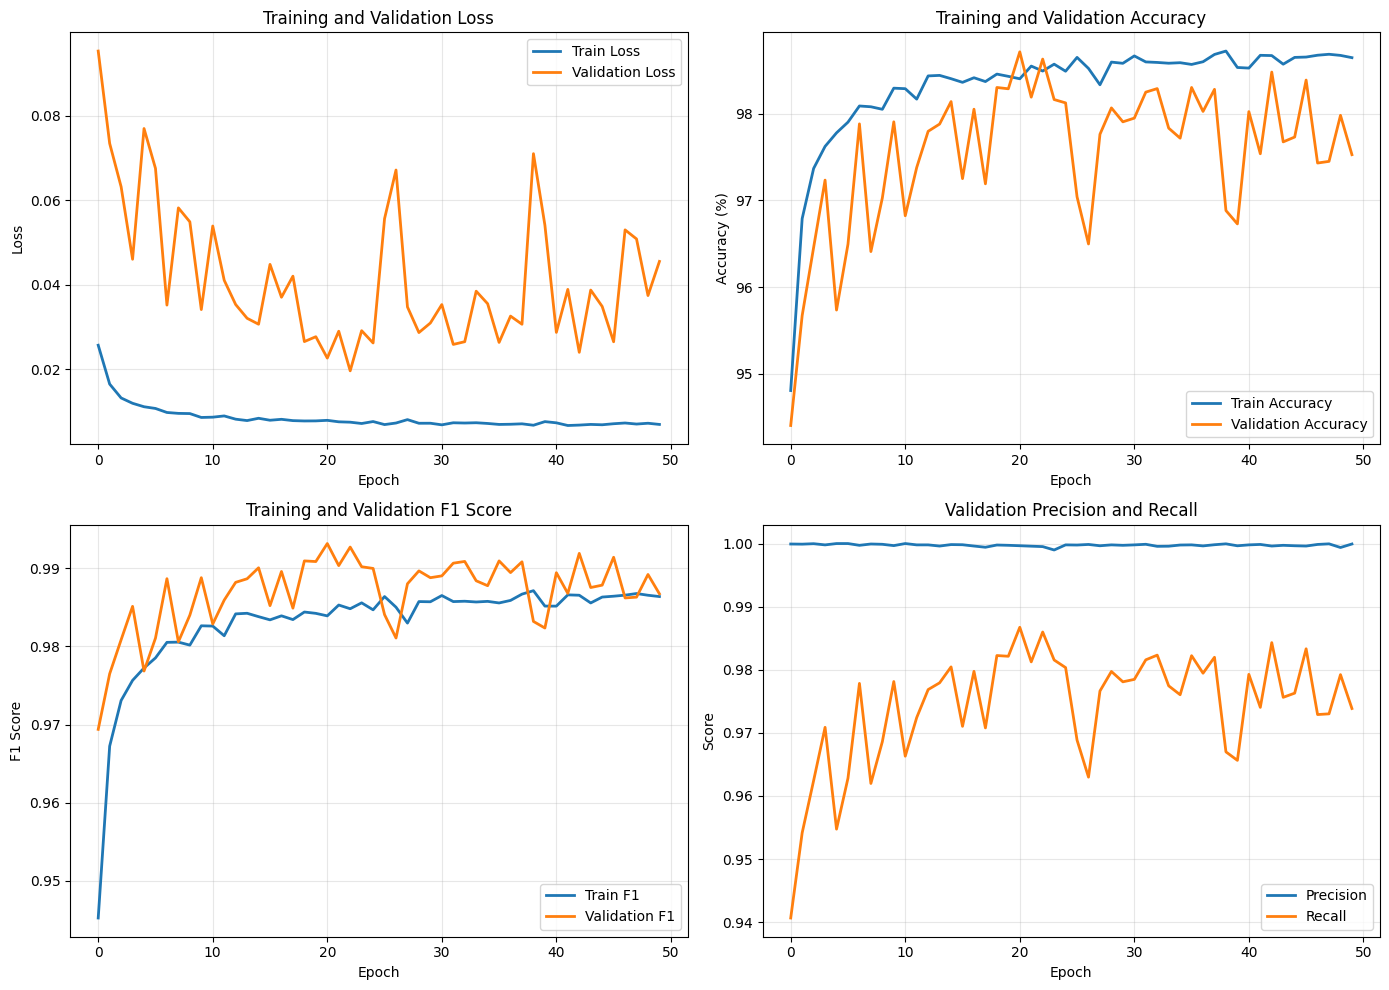

In [14]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(train_accuracies, label='Train Accuracy', linewidth=2)
axes[0, 1].plot(val_accuracies, label='Validation Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[1, 0].plot(train_f1_scores, label='Train F1', linewidth=2)
axes[1, 0].plot(val_f1_scores, label='Validation F1', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Training and Validation F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision and Recall
axes[1, 1].plot(val_precisions, label='Precision', linewidth=2)
axes[1, 1].plot(val_recalls, label='Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Validation Precision and Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


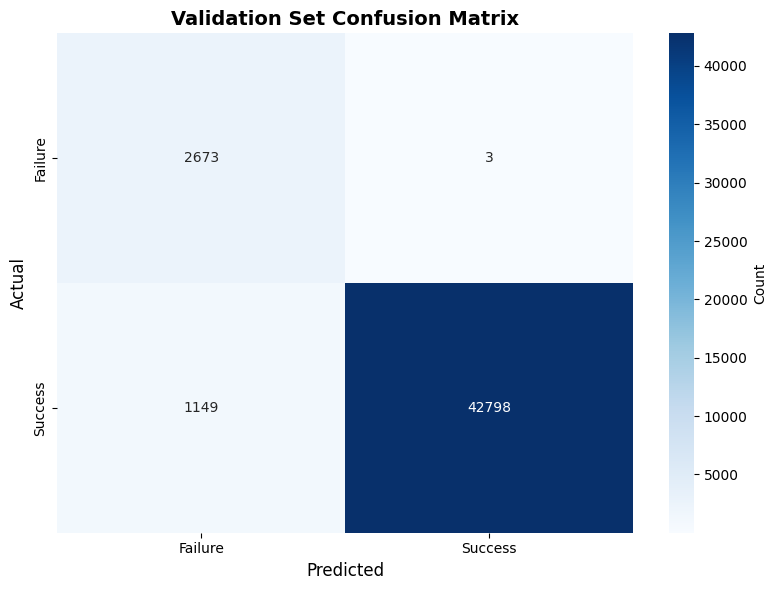

In [15]:
# Plot confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cm = confusion_matrix(val_labels, val_preds)

try:
    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Failure', 'Success'],
                yticklabels=['Failure', 'Success'],
                cbar_kws={'label': 'Count'})
except ImportError:
    # Fallback if seaborn not available
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Count')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', 
                   fontsize=16, fontweight='bold', color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Failure', 'Success'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Failure', 'Success'])

ax.set_title('Validation Set Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


In [16]:
# Save the trained model
model_save_path = 'trajectory_classifier_cnn.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {'num_features': 5, 'num_classes': 2},
    'class_weights': class_weights,
    'best_val_f1': best_val_f1,
    'num_epochs': num_epochs,
}, model_save_path)

print(f"✓ Model saved to {model_save_path}")
print(f"  Best validation F1: {best_val_f1:.4f}")


✓ Model saved to trajectory_classifier_cnn.pth
  Best validation F1: 0.9932


In [17]:
# Load test data directly from roa_labels.txt
# roa_labels.txt already contains individual datapoints (one per row)
# Format: [x, theta, x_dot, theta_dot, label] (5 columns)
# We need to transform to [x, sin(theta), cos(theta), x_dot, theta_dot] for the model

test_start_index = 1000  # Skip first 1000 rows (used for training)

# Load roa_labels.txt - each row is already an individual datapoint
labels_data = np.loadtxt('roa_labels.txt', delimiter=',')

# Get test data (rows 1000 onwards)
test_data = labels_data[test_start_index:]

print(f"Loading test data from roa_labels.txt (starting from row {test_start_index})...")
print(f"Total rows in roa_labels.txt: {len(labels_data)}")
print(f"Test datapoints: {len(test_data)}")

# Extract features and labels
# Features: columns 0-3 are [x, theta, x_dot, theta_dot]
# Label: column 4 (last column)
test_features_raw = test_data[:, :4]  # [x, theta, x_dot, theta_dot]
y_test = test_data[:, 4].astype(int)  # Labels

# Transform features: [x, theta, x_dot, theta_dot] -> [x, sin(theta), cos(theta), x_dot, theta_dot]
X_test = np.zeros((len(test_features_raw), 5), dtype=np.float32)
X_test[:, 0] = test_features_raw[:, 0]  # x
X_test[:, 1] = np.sin(test_features_raw[:, 1])  # sin(theta)
X_test[:, 2] = np.cos(test_features_raw[:, 1])  # cos(theta)
X_test[:, 3] = test_features_raw[:, 2]  # x_dot
X_test[:, 4] = test_features_raw[:, 3]  # theta_dot

# Normalize test data using the same max values from training
# Only normalize features [0], [3], [4] (x, x_dot, theta_dot)
# Do NOT normalize features [1], [2] (sin(theta), cos(theta))
# feature_max should be defined from training data normalization
if 'feature_max' not in globals():
    raise ValueError("feature_max not found! Please run training data loading cell first.")
print(f"\nNormalizing test data using training max values...")
print(f"Feature max values: {feature_max}")
print(f"Normalizing only features [0, 3, 4] (x, x_dot, theta_dot)")
X_test[:, [0, 3, 4]] = X_test[:, [0, 3, 4]] / feature_max[[0, 3, 4]]

print(f"X_test shape: {X_test.shape}  (datapoints, features)")
print(f"y_test shape: {y_test.shape}  (labels)")
print(f"X_test normalized range: [{X_test.min():.4f}, {X_test.max():.4f}]")
print(f"Success rate: {np.mean(y_test == 1):.2%}")
print(f"Failure rate: {np.mean(y_test == 0):.2%}")

Loading test data from roa_labels.txt (starting from row 1000)...
Total rows in roa_labels.txt: 116242
Test datapoints: 115242

Normalizing test data using training max values...
Feature max values: [6.039033   0.99999976 1.         7.083724   8.18666   ]
Normalizing only features [0, 3, 4] (x, x_dot, theta_dot)
X_test shape: (115242, 5)  (datapoints, features)
y_test shape: (115242,)  (labels)
X_test normalized range: [-1.0000, 0.9900]
Success rate: 17.96%
Failure rate: 82.04%


In [18]:
# VERIFY TEST DATA: Print detailed information about what's being tested
print("=" * 80)
print("TEST DATA VERIFICATION")
print("=" * 80)

print("\n--- TEST DATA SUMMARY ---")
print(f"X_test shape: {X_test.shape}")
print(f"  - Number of individual datapoints: {X_test.shape[0]}")
print(f"  - Features per datapoint: {X_test.shape[1]} (should be 5: [x, sin(theta), cos(theta), x_dot, theta_dot])")
print(f"y_test shape: {y_test.shape}")
print(f"  - Number of labels: {len(y_test)}")
print(f"  - Unique labels: {np.unique(y_test)}")
print(f"  - Success (1): {np.sum(y_test == 1)} ({np.mean(y_test == 1):.2%})")
print(f"  - Failure (0): {np.sum(y_test == 0)} ({np.mean(y_test == 0):.2%})")

# Show sample test datapoints
print("\n--- SAMPLE TEST DATAPOINTS ---")
print(f"First 5 test datapoints:")
for i in range(min(5, len(X_test))):
    dp = X_test[i]
    print(f"  Datapoint {i}: {dp}")
    print(f"    x={dp[0]:.6f}, sin(theta)={dp[1]:.6f}, cos(theta)={dp[2]:.6f}, x_dot={dp[3]:.6f}, theta_dot={dp[4]:.6f}")
    print(f"    Label: {y_test[i]} ({'Success' if y_test[i] == 1 else 'Failure'})")

# Check data statistics
print("\n--- TEST DATA STATISTICS ---")
print("X_test statistics (per feature):")
feature_names = ['x', 'sin(theta)', 'cos(theta)', 'x_dot', 'theta_dot']
for i, name in enumerate(feature_names):
    print(f"  {name:15s}: min={X_test[:, i].min():8.4f}, max={X_test[:, i].max():8.4f}, mean={X_test[:, i].mean():8.4f}, std={X_test[:, i].std():8.4f}")

# Verify data types
print("\n--- DATA TYPES ---")
print(f"X_test dtype: {X_test.dtype}")
print(f"y_test dtype: {y_test.dtype}")

# Check for any NaN or Inf values
print("\n--- DATA QUALITY CHECK ---")
print(f"X_test has NaN: {np.isnan(X_test).any()}")
print(f"X_test has Inf: {np.isinf(X_test).any()}")
print(f"y_test has NaN: {np.isnan(y_test).any()}")

print("\n--- TESTING APPROACH ---")
print("The model will be tested on individual state vectors (datapoints).")
print("Each datapoint is classified as:")
print("  - 1 (Success): if it came from a successful trajectory")
print("  - 0 (Failure): if it came from a failed trajectory")
print("The model predicts whether a single state vector belongs to a success or failure trajectory.")

print("\n" + "=" * 80)
print("TEST DATA VERIFICATION COMPLETE")
print("=" * 80)


TEST DATA VERIFICATION

--- TEST DATA SUMMARY ---
X_test shape: (115242, 5)
  - Number of individual datapoints: 115242
  - Features per datapoint: 5 (should be 5: [x, sin(theta), cos(theta), x_dot, theta_dot])
y_test shape: (115242,)
  - Number of labels: 115242
  - Unique labels: [0 1]
  - Success (1): 20692 (17.96%)
  - Failure (0): 94550 (82.04%)

--- SAMPLE TEST DATAPOINTS ---
First 5 test datapoints:
  Datapoint 0: [ 0.579563   -0.99749494 -0.07073755  0.07058434 -0.30537486]
    x=0.579563, sin(theta)=-0.997495, cos(theta)=-0.070738, x_dot=0.070584, theta_dot=-0.305375
    Label: 0 (Failure)
  Datapoint 1: [ 0.08279471 -0.8414708  -0.5403026  -0.42350605  0.42752478]
    x=0.082795, sin(theta)=-0.841471, cos(theta)=-0.540303, x_dot=-0.423506, theta_dot=0.427525
    Label: 0 (Failure)
  Datapoint 2: [ 0.41397357 -0.5984724   0.8011434  -0.28233737  0.30537486]
    x=0.413974, sin(theta)=-0.598472, cos(theta)=0.801143, x_dot=-0.282337, theta_dot=0.305375
    Label: 1 (Success)
  D

In [19]:
# Create test dataset and dataloader
test_dataset = TimestepDataset(X_test, y_test)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

print(f"Test dataset size: {len(test_dataset)} timesteps")
print(f"Test batches: {len(test_loader)}")

Test dataset size: 115242 timesteps
Test batches: 3602


In [20]:
# Evaluate on test set with threshold-based classification (0.1/0.9)
# Threshold: < 0.1 = failure (0), > 0.9 = success (1), 0.1-0.9 = uncertain (classify to nearest)
# Use ROA labels from roa_labels.txt for evaluation
failure_threshold = 0.1
success_threshold = 0.9

# Create test dataset and dataloader
test_dataset = TimestepDataset(X_test, y_test)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

model.eval()
all_test_preds = []
all_test_labels = []
all_test_probs = []  # Store probabilities for analysis

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        outputs = model(batch_X)
        
        # Apply softmax to get probabilities
        probs = torch.softmax(outputs, dim=1)
        prob_success = probs[:, 1].cpu().numpy()  # Probability of success (class 1)
        
        # Threshold-based classification
        # < 0.1: failure (0), > 0.9: success (1), 0.1-0.9: uncertain (-1)
        predicted = np.where(prob_success < failure_threshold, 0, np.where(prob_success > success_threshold, 1, -1))  # In uncertain zone, mark as -1
        
        all_test_preds.extend(predicted)
        # Use ROA labels from y_test
        all_test_labels.extend(batch_y.cpu().numpy())
        all_test_probs.extend(prob_success)

all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)
all_test_probs = np.array(all_test_probs)

# Count uncertain predictions (between thresholds) - these are marked as -1
uncertain_mask = (all_test_preds == -1)
num_uncertain = np.sum(uncertain_mask)

print(f"Threshold-based classification:")
print(f"  Failure threshold: < {failure_threshold}")
print(f"  Success threshold: > {success_threshold}")
print(f"  Uncertain zone ({failure_threshold}-{success_threshold}): {num_uncertain} samples ({num_uncertain/len(all_test_preds)*100:.2f}%)")
print()

# Remove uncertain predictions (-1) and corresponding labels before calculating metrics
valid_mask = (all_test_preds != -1)
all_test_preds_filtered = all_test_preds[valid_mask]
all_test_labels_filtered = all_test_labels[valid_mask]
num_removed = num_uncertain

print(f"Removed {num_removed} uncertain samples ({num_removed/len(all_test_preds)*100:.2f}%)")
print(f"Remaining samples for evaluation: {len(all_test_preds_filtered)}")
print()

# Calculate metrics on filtered data (without uncertain predictions)
test_accuracy = accuracy_score(all_test_labels_filtered, all_test_preds_filtered)
test_precision = precision_score(all_test_labels_filtered, all_test_preds_filtered)
test_recall = recall_score(all_test_labels_filtered, all_test_preds_filtered)
test_f1 = f1_score(all_test_labels_filtered, all_test_preds_filtered)
test_cm = confusion_matrix(all_test_labels_filtered, all_test_preds_filtered)

print("=" * 60)
print("TEST SET RESULTS (Threshold-based Classification: 0.1/0.9)")
print("=" * 60)
print(f"Total test samples (before filtering): {len(all_test_labels)}")
print(f"Uncertain samples removed: {num_removed}")
print(f"Remaining samples: {len(all_test_labels_filtered)}")
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print()
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Failure  Success")
print(f"Actual Failure  {test_cm[0,0]:6d}  {test_cm[0,1]:6d}")
print(f"        Success  {test_cm[1,0]:6d}  {test_cm[1,1]:6d}")
print()
print("Classification Report:")
print(classification_report(all_test_labels_filtered, all_test_preds_filtered, target_names=['Failure', 'Success']))


Threshold-based classification:
  Failure threshold: < 0.1
  Success threshold: > 0.9
  Uncertain zone (0.1-0.9): 6051 samples (5.25%)

Removed 6051 uncertain samples (5.25%)
Remaining samples for evaluation: 109191

TEST SET RESULTS (Threshold-based Classification: 0.1/0.9)
Total test samples (before filtering): 115242
Uncertain samples removed: 6051
Remaining samples: 109191
Accuracy: 93.88%
Precision: 0.9963
Recall:    0.5581
F1 Score:  0.7154

Confusion Matrix:
              Predicted
              Failure  Success
Actual Failure   94099      31
        Success    6656    8405

Classification Report:
              precision    recall  f1-score   support

     Failure       0.93      1.00      0.97     94130
     Success       1.00      0.56      0.72     15061

    accuracy                           0.94    109191
   macro avg       0.97      0.78      0.84    109191
weighted avg       0.94      0.94      0.93    109191



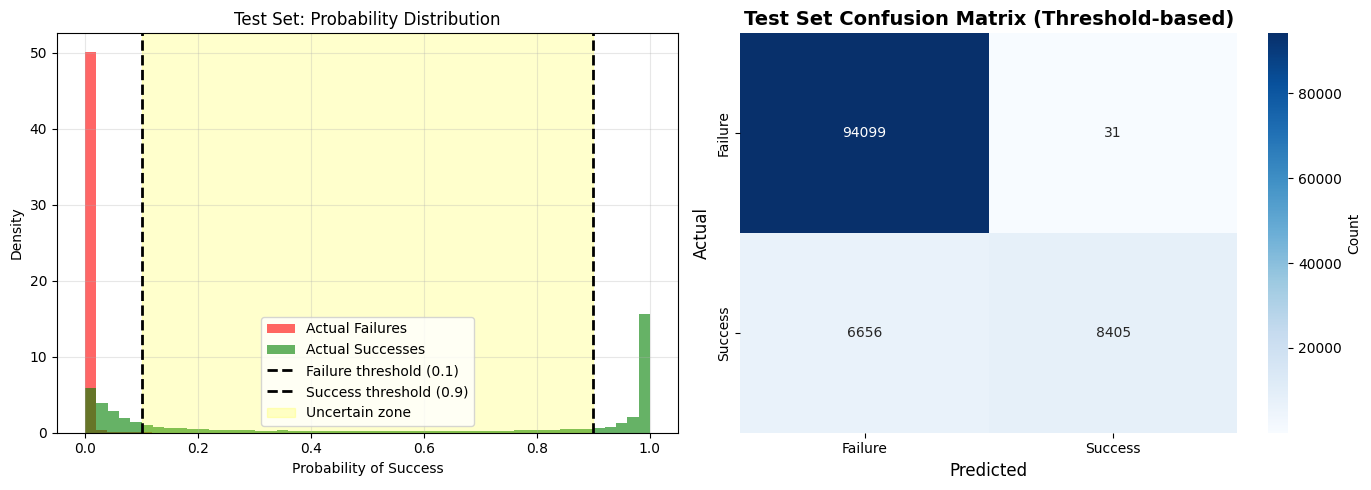

In [21]:
# Plot probability distribution and threshold zones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Probability distribution histogram
axes[0].hist(all_test_probs[all_test_labels == 0], bins=50, alpha=0.6, label='Actual Failures', color='red', density=True)
axes[0].hist(all_test_probs[all_test_labels == 1], bins=50, alpha=0.6, label='Actual Successes', color='green', density=True)
axes[0].axvline(failure_threshold, color='black', linestyle='--', linewidth=2, label=f'Failure threshold ({failure_threshold})')
axes[0].axvline(success_threshold, color='black', linestyle='--', linewidth=2, label=f'Success threshold ({success_threshold})')
axes[0].axvspan(failure_threshold, success_threshold, alpha=0.2, color='yellow', label='Uncertain zone')
axes[0].set_xlabel('Probability of Success')
axes[0].set_ylabel('Density')
axes[0].set_title('Test Set: Probability Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix
ax = axes[1]

try:
    import seaborn as sns
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Failure', 'Success'],
                yticklabels=['Failure', 'Success'],
                cbar_kws={'label': 'Count'})
except ImportError:
    # Fallback if seaborn not available
    im = ax.imshow(test_cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Count')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(test_cm[i, j]), ha='center', va='center', 
                   fontsize=16, fontweight='bold', color='white' if test_cm[i, j] > test_cm.max()/2 else 'black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Failure', 'Success'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Failure', 'Success'])

ax.set_title('Test Set Confusion Matrix (Threshold-based)', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()


In [22]:
# Evaluate on test set with threshold-based classification (0.4/0.6)
# Threshold: < 0.4 = failure (0), > 0.6 = success (1), 0.4-0.6 = uncertain (classify to nearest)
# Use ROA labels from roa_labels.txt for evaluation
failure_threshold_46 = 0.4
success_threshold_46 = 0.6

model.eval()
all_test_preds_46 = []
all_test_labels_46 = []
all_test_probs_46 = []  # Store probabilities for analysis

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        outputs = model(batch_X)
        
        # Apply softmax to get probabilities
        probs = torch.softmax(outputs, dim=1)
        prob_success = probs[:, 1].cpu().numpy()  # Probability of success (class 1)
        
        # Threshold-based classification
        # < 0.4: failure (0), > 0.6: success (1), 0.4-0.6: uncertain (-1)
        predicted = np.where(prob_success < failure_threshold_46, 0,
                    np.where(prob_success > success_threshold_46, 1, -1))  # In uncertain zone, mark as -1
        
        all_test_preds_46.extend(predicted)
        # Use ROA labels from y_test
        all_test_labels_46.extend(batch_y.cpu().numpy())
        all_test_probs_46.extend(prob_success)

all_test_preds_46 = np.array(all_test_preds_46)
all_test_labels_46 = np.array(all_test_labels_46)
all_test_probs_46 = np.array(all_test_probs_46)

# Count uncertain predictions (between thresholds) - these are marked as -1
uncertain_mask_46 = (all_test_preds_46 == -1)
num_uncertain_46 = np.sum(uncertain_mask_46)

print(f"Threshold-based classification:")
print(f"  Failure threshold: < {failure_threshold_46}")
print(f"  Success threshold: > {success_threshold_46}")
print(f"  Uncertain zone ({failure_threshold_46}-{success_threshold_46}): {num_uncertain_46} samples ({num_uncertain_46/len(all_test_preds_46)*100:.2f}%)")
print()

# Remove uncertain predictions (-1) and corresponding labels before calculating metrics
valid_mask_46 = (all_test_preds_46 != -1)
all_test_preds_46_filtered = all_test_preds_46[valid_mask_46]
all_test_labels_46_filtered = all_test_labels_46[valid_mask_46]
num_removed_46 = num_uncertain_46

print(f"Removed {num_removed_46} uncertain samples ({num_removed_46/len(all_test_preds_46)*100:.2f}%)")
print(f"Remaining samples for evaluation: {len(all_test_preds_46_filtered)}")
print()

# Calculate metrics on filtered data (without uncertain predictions)
test_accuracy_46 = accuracy_score(all_test_labels_46_filtered, all_test_preds_46_filtered)
test_precision_46 = precision_score(all_test_labels_46_filtered, all_test_preds_46_filtered)
test_recall_46 = recall_score(all_test_labels_46_filtered, all_test_preds_46_filtered)
test_f1_46 = f1_score(all_test_labels_46_filtered, all_test_preds_46_filtered)
test_cm_46 = confusion_matrix(all_test_labels_46_filtered, all_test_preds_46_filtered)

print("=" * 60)
print("TEST SET RESULTS (Threshold-based Classification: 0.4/0.6)")
print("=" * 60)
print(f"Total test samples (before filtering): {len(all_test_labels_46)}")
print(f"Uncertain samples removed: {num_removed_46}")
print(f"Remaining samples: {len(all_test_labels_46_filtered)}")
print(f"Accuracy: {test_accuracy_46*100:.2f}%")
print(f"Precision: {test_precision_46:.4f}")
print(f"Recall:    {test_recall_46:.4f}")
print(f"F1 Score:  {test_f1_46:.4f}")
print()
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Failure  Success")
print(f"Actual Failure  {test_cm_46[0,0]:6d}  {test_cm_46[0,1]:6d}")
print(f"        Success  {test_cm_46[1,0]:6d}  {test_cm_46[1,1]:6d}")
print()
print("Classification Report:")
print(classification_report(all_test_labels_46_filtered, all_test_preds_46_filtered, target_names=['Failure', 'Success']))


Threshold-based classification:
  Failure threshold: < 0.4
  Success threshold: > 0.6
  Uncertain zone (0.4-0.6): 970 samples (0.84%)

Removed 970 uncertain samples (0.84%)
Remaining samples for evaluation: 114272

TEST SET RESULTS (Threshold-based Classification: 0.4/0.6)
Total test samples (before filtering): 115242
Uncertain samples removed: 970
Remaining samples: 114272
Accuracy: 91.67%
Precision: 0.9907
Recall:    0.5236
F1 Score:  0.6851

Confusion Matrix:
              Predicted
              Failure  Success
Actual Failure   94402      97
        Success    9420   10353

Classification Report:
              precision    recall  f1-score   support

     Failure       0.91      1.00      0.95     94499
     Success       0.99      0.52      0.69     19773

    accuracy                           0.92    114272
   macro avg       0.95      0.76      0.82    114272
weighted avg       0.92      0.92      0.91    114272



In [23]:
# Calculate all metrics for table (Threshold-based method)
# Confusion matrix: [[TN, FP], [FN, TP]]
# test_cm[0,0] = True Negatives (TN) - predicted failure, actual failure
# test_cm[0,1] = False Positives (FP) - predicted success, actual failure
# test_cm[1,0] = False Negatives (FN) - predicted failure, actual success
# test_cm[1,1] = True Positives (TP) - predicted success, actual success

TN = test_cm[0, 0]
FP = test_cm[0, 1]
FN = test_cm[1, 0]
TP = test_cm[1, 1]

# Calculate additional metrics
Specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # True Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate (same as Recall)
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate
TNR = Specificity  # True Negative Rate (same as Specificity)
FNR = FN / (FN + TP) if (FN + TP) > 0 else 0  # False Negative Rate

# Separatrix: the uncertain zone (0.4-0.6) - percentage of samples in this zone
# Use variables from 0.4/0.6 evaluation (cell 22)
separatrix = num_uncertain_46 / len(all_test_preds_46) * 100

# Use confusion matrix from 0.4/0.6 evaluation
TN = test_cm_46[0, 0]
FP = test_cm_46[0, 1]
FN = test_cm_46[1, 0]
TP = test_cm_46[1, 1]

# Calculate additional metrics
Specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # True Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate (same as Recall)
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate
TNR = Specificity  # True Negative Rate (same as Specificity)
FNR = FN / (FN + TP) if (FN + TP) > 0 else 0  # False Negative Rate

print("=" * 80)
print("METRICS FOR TABLE (Threshold-based Method: 0.4/0.6)")
print("=" * 80)
print(f"Method Name: Threshold-based CNN")
print(f"# Training Trajs: 1000")
print(f"Prob Threshold: < 0.4 (failure), > 0.6 (success)")
print(f"Separatrix (uncertain zone %): {separatrix:.2f}%")
print(f"Accuracy: {test_accuracy_46*100:.2f}%")
print(f"Precision: {test_precision_46:.4f}")
print(f"Recall: {test_recall_46:.4f}")
print(f"F1: {test_f1_46:.4f}")
print(f"Specificity: {Specificity:.4f}")
print(f"True Positive Rate (TPR): {TPR:.4f}")
print(f"False Positive Rate (FPR): {FPR:.4f}")
print(f"True Negative Rate (TNR): {TNR:.4f}")
print(f"False Negative Rate (FNR): {FNR:.4f}")
print()
print("Confusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {TN}")
print(f"  False Positives (FP): {FP}")
print(f"  False Negatives (FN): {FN}")
print(f"  True Positives (TP):  {TP}")
print()
print("=" * 80)
print("COPY-PASTE FOR TABLE:")
print("=" * 80)
print(f"Threshold-based\t1000\t0.4/0.6\t{separatrix:.2f}%\t{test_accuracy_46*100:.2f}%\t{test_precision_46:.4f}\t{test_recall_46:.4f}\t{test_f1_46:.4f}\t{Specificity:.4f}\t{TPR:.4f}\t{FPR:.4f}\t{TNR:.4f}\t{FNR:.4f}")


METRICS FOR TABLE (Threshold-based Method: 0.4/0.6)
Method Name: Threshold-based CNN
# Training Trajs: 1000
Prob Threshold: < 0.4 (failure), > 0.6 (success)
Separatrix (uncertain zone %): 0.84%
Accuracy: 91.67%
Precision: 0.9907
Recall: 0.5236
F1: 0.6851
Specificity: 0.9990
True Positive Rate (TPR): 0.5236
False Positive Rate (FPR): 0.0010
True Negative Rate (TNR): 0.9990
False Negative Rate (FNR): 0.4764

Confusion Matrix Breakdown:
  True Negatives (TN):  94402
  False Positives (FP): 97
  False Negatives (FN): 9420
  True Positives (TP):  10353

COPY-PASTE FOR TABLE:
Threshold-based	1000	0.4/0.6	0.84%	91.67%	0.9907	0.5236	0.6851	0.9990	0.5236	0.0010	0.9990	0.4764


In [ ]:
import seaborn as sns

In [ ]:
# Compare validation and test performance
# Try to import seaborn for better plots
try:
    import seaborn as sns
    has_seaborn = True
except ImportError:
    has_seaborn = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
val_metrics = [val_acc*100, val_prec*100, val_rec*100, val_f1*100]
test_metrics = [test_accuracy*100, test_precision*100, test_recall*100, test_f1*100]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, val_metrics, width, label='Validation', alpha=0.8)
axes[0].bar(x + width/2, test_metrics, width, label='Test', alpha=0.8)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Validation vs Test Performance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 105])

# Add value labels on bars
for i, (v, t) in enumerate(zip(val_metrics, test_metrics)):
    axes[0].text(i - width/2, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, t + 1, f'{t:.1f}%', ha='center', va='bottom', fontsize=9)

# Confusion matrices side by side
axes[1].axis('off')
axes[1].text(0.5, 0.95, 'Validation Set', ha='center', fontsize=12, fontweight='bold', transform=axes[1].transAxes)
axes[1].text(0.5, 0.5, 'Test Set', ha='center', fontsize=12, fontweight='bold', transform=axes[1].transAxes)

# Create subplot for confusion matrices
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Validation confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes2[0])
if has_seaborn:
    im1 = axes2[0].imshow(cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im1, ax=axes2[0], label='Count')
    for i in range(2):
        for j in range(2):
            axes2[0].text(j, i, str(cm[i, j]), ha='center', va='center', 
                         fontsize=14, fontweight='bold', 
                         color='white' if cm[i, j] > cm.max()/2 else 'black')
    axes2[0].set_xticks([0, 1])
    axes2[0].set_xticklabels(['Failure', 'Success'])
    axes2[0].set_yticks([0, 1])
    axes2[0].set_yticklabels(['Failure', 'Success'])

axes2[0].set_title('Validation Set', fontsize=12, fontweight='bold')
axes2[0].set_ylabel('Actual', fontsize=10)
axes2[0].set_xlabel('Predicted', fontsize=10)

# Test confusion matrix
if has_seaborn:
    im2 = axes2[1].imshow(test_cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im2, ax=axes2[1], label='Count')
    for i in range(2):
        for j in range(2):
            axes2[1].text(j, i, str(test_cm[i, j]), ha='center', va='center', 
                         fontsize=14, fontweight='bold', 
                         color='white' if test_cm[i, j] > test_cm.max()/2 else 'black')
    axes2[1].set_xticks([0, 1])
    axes2[1].set_xticklabels(['Failure', 'Success'])
    axes2[1].set_yticks([0, 1])
    axes2[1].set_yticklabels(['Failure', 'Success'])

axes2[1].set_title('Test Set', fontsize=12, fontweight='bold')
axes2[1].set_ylabel('Actual', fontsize=10)
axes2[1].set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# [x, sin(theta), cos(theta), x_dot, theta_dot]
all_thetas = []
all_theta_dots = []
all_outcomes = []

for i in range(len(X_test)):
    datapoint = X_test[i, :]
    
    sin_theta = datapoint[1] 
    cos_theta = datapoint[2] 
    theta = np.arctan2(sin_theta, cos_theta) 
    
    theta_dot = datapoint[4] 
    
    outcome = y_test[i]
    
    all_thetas.append(theta)
    all_theta_dots.append(theta_dot)
    all_outcomes.append(outcome)

all_thetas = np.array(all_thetas)
all_theta_dots = np.array(all_theta_dots)
all_outcomes = np.array(all_outcomes)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.scatter(all_thetas, all_theta_dots, c=all_outcomes, cmap='viridis', s=0.1, alpha=0.8, edgecolors='none')
ax.set_xlabel('theta (radians)', fontsize=12)
ax.set_ylabel('theta dot (radians/s)', fontsize=12)
ax.set_title('theta vs theta_dot', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Success rate: {np.mean(all_outcomes == 1):.2%}")
print(f"Failure rate: {np.mean(all_outcomes == 0):.2%}")